[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/drdave-teaching/OPIM5509-notebooks/blob/main/Module4/Simple_Predict_The_Stock_Market_DL.ipynb)

🔴
<!-- 🎙 DAVE TALKING POINTS — M4 · 11 — Predict the stock market (an honest result)
- Prices now load from a stable CSV snapshot in the repo (the old live scrape died) - 11 tickers, 2017-12-27 to 2020-01-22; a commented yfinance cell is there for fresh data.
- Percent change as the return; label Walmart's NEXT-day up/down (shift by 1 - no same-day cheating).
- StandardScaler, 50/50 chronological, look-back 5, 11 features; stacked LSTMs + dropout, patience 20.
- Result: barely beats 50%, weighted F1 under 0.5, lots of false positives. DON'T TRADE ON IT - that's the lesson, and it's the best video in the module.
-->


# (Simple) Predict the Stock Market!
--------------------------
**Dr. Dave Wanik - University of Connecticut**

Can yesterday's returns across eleven tickers tell us whether Walmart goes up tomorrow? We'll build the sequences, fit stacked LSTMs, and read the result honestly - this one is about knowing when a model *isn't* good enough to act on.

In [1]:
# some useful modules
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from keras.models import Sequential
from keras.layers import Dense, LSTM, GRU, Dropout, Bidirectional, Flatten, Conv1D, MaxPooling1D
from keras.callbacks import EarlyStopping
from keras.utils import to_categorical
from keras import layers

# reproducibility: same seed every run (numbers on CPU match exactly; a GPU may drift a little)
import keras
keras.utils.set_random_seed(5509)


In [2]:
# Stock prices come from a STABLE snapshot in the course repo (adjusted closes, 2017-12-27 to 2020-01-22,
# 11 tickers). The original live scrape no longer works - Yahoo changed - and a scraper in a class
# notebook is a ticking time bomb anyway. If you want FRESH data, see the commented yfinance cell below.
tickers_list = ['NFLX','IBM','GE','GOOG','AAPL','KO','AMZN','HD','NKE','^DJI','WMT']
url = "https://raw.githubusercontent.com/drdave-teaching/OPIM5509Files/main/OPIM5509_Module4_Files/data/stock_adjclose_2017_2020.csv"
prep_data = pd.read_csv(url, index_col='date', parse_dates=True)[tickers_list]
prep_data.head()

,NFLX,IBM,GE,GOOG,AAPL,KO,AMZN,HD,NKE,^DJI,WMT
date,,,,,,,,,,,
2017-12-27,18.624,101.1861,78.2517,51.9762,39.8447,35.3242,59.1130,153.2720,55.3548,24774.3008,28.9267
2017-12-28,19.271,101.7873,78.1617,51.9153,39.9568,35.1627,59.3050,152.9416,55.3548,24837.5098,28.9675
2017-12-29,19.196,101.3776,78.5669,51.8291,39.5247,35.2857,58.4735,152.7401,55.0030,24719.2207,28.7781
2018-01-02,20.107,101.9261,80.9531,52.7504,40.2324,35.0242,59.4505,151.5313,55.8296,24824.0098,28.7315
2018-01-03,20.505,104.7278,81.7186,53.6162,40.2254,34.9473,60.2100,152.3210,55.8208,24922.6797,28.9821


In [3]:
# want fresh prices instead? (optional - not needed for the lecture)
# !pip -q install yfinance
# import yfinance as yf
# raw = yf.download(tickers_list, start='2017-12-27', end='2020-01-23', auto_adjust=False, progress=False)
# prep_data = raw['Adj Close'][tickers_list]

In [4]:
# take a peek - one column of adjusted closes per ticker, one row per trading day
prep_data.tail()

,NFLX,IBM,GE,GOOG,AAPL,KO,AMZN,HD,NKE,^DJI,WMT
date,,,,,,,,,,,
2020-01-15,33.907,98.8856,57.3855,71.2848,74.9160,46.5450,93.101,190.1257,92.3770,29030.2207,35.0892
2020-01-16,33.862,99.8700,57.2405,71.9040,75.8544,46.6435,93.897,193.7067,92.8982,29297.6406,35.2780
2020-01-17,33.967,100.1088,57.0955,73.3250,76.6942,46.7420,93.236,196.3224,93.9408,29348.0996,34.9918
2020-01-21,33.811,100.7313,56.3703,73.5236,76.1745,46.9308,94.600,197.2029,93.9857,29196.0391,35.1836
2020-01-22,32.600,104.1476,54.9683,73.6004,76.4464,47.2920,94.373,197.1605,93.9048,29186.2695,35.3388


In [5]:
# 520 trading days x 11 tickers, no gaps
print(prep_data.shape)
prep_data.isna().sum()

(520, 11)


NFLX    0
IBM     0
GE      0
GOOG    0
AAPL    0
KO      0
AMZN    0
HD      0
NKE     0
^DJI    0
WMT     0
dtype: int64

In [6]:
prep_data.shape

(520, 11)

Rather than use the raw time series, let's build a model based on past returns (the difference from the previous day).

In [7]:
# create return features for each ticker,
# we will just use a pct_change as the return
return_data = pd.DataFrame()
for i in tickers_list:
  return_data[i] = prep_data[i].pct_change()
# drop the na records
return_data.dropna(inplace=True)
return_data

,NFLX,IBM,GE,GOOG,AAPL,KO,AMZN,HD,NKE,^DJI,WMT
date,,,,,,,,,,,
2017-12-28,0.034740,0.005942,-0.001150,-0.001172,0.002813,-0.004572,0.003248,-0.002156,0.000000,0.002551,0.001410
2017-12-29,-0.003892,-0.004025,0.005184,-0.001660,-0.010814,0.003498,-0.014021,-0.001317,-0.006355,-0.004763,-0.006538
2018-01-02,0.047458,0.005410,0.030372,0.017776,0.017905,-0.007411,0.016708,-0.007914,0.015028,0.004239,-0.001619
2018-01-03,0.019794,0.027488,0.009456,0.016413,-0.000174,-0.002196,0.012775,0.005211,-0.000158,0.003975,0.008722
2018-01-04,0.002829,0.020253,0.020936,0.003620,0.004644,0.014084,0.004476,0.007937,-0.000631,0.006117,0.000904
...,...,...,...,...,...,...,...,...,...,...,...
2020-01-15,0.001122,0.005890,-0.013300,0.005815,-0.004285,0.012499,-0.003969,0.007989,-0.001264,0.003129,-0.007748
2020-01-16,-0.001327,0.009955,-0.002527,0.008686,0.012526,0.002116,0.008550,0.018835,0.005642,0.009212,0.005381
2020-01-17,0.003101,0.002391,-0.002533,0.019762,0.011071,0.002112,-0.007040,0.013503,0.011223,0.001722,-0.008113


In [8]:
return_data.shape

(519, 11)

# Pre-processing

In [9]:
# now, let's make a copy of that data and call it df
df = return_data

# Create Target Variable

In [10]:
# create binary target
# if Walmart is pos, 1, otherwise, 0
df['Increase'] = np.where(df['WMT']>0,
                          1, # if true
                          0) # if false
df.head(n=10)

,NFLX,IBM,GE,GOOG,AAPL,KO,AMZN,HD,NKE,^DJI,WMT,Increase
date,,,,,,,,,,,,
2017-12-28,0.034740,0.005942,-0.001150,-0.001172,0.002813,-0.004572,0.003248,-0.002156,0.000000,0.002551,0.001410,1
2017-12-29,-0.003892,-0.004025,0.005184,-0.001660,-0.010814,0.003498,-0.014021,-0.001317,-0.006355,-0.004763,-0.006538,0
2018-01-02,0.047458,0.005410,0.030372,0.017776,0.017905,-0.007411,0.016708,-0.007914,0.015028,0.004239,-0.001619,0
2018-01-03,0.019794,0.027488,0.009456,0.016413,-0.000174,-0.002196,0.012775,0.005211,-0.000158,0.003975,0.008722,1
2018-01-04,0.002829,0.020253,0.020936,0.003620,0.004644,0.014084,0.004476,0.007937,-0.000631,0.006117,0.000904,1
2018-01-05,0.021203,0.004886,0.000539,0.014572,0.011385,-0.000214,0.016163,0.010446,0.008513,0.008803,0.005926,1
2018-01-08,0.009810,0.006031,-0.014023,0.004273,-0.003714,-0.001521,0.014425,-0.002390,0.008909,-0.000509,0.014784,1
2018-01-09,-0.012921,0.002201,0.015316,-0.000615,-0.000115,0.005000,0.004676,0.005519,-0.007126,0.004066,-0.012009,0
2018-01-10,0.015336,0.002137,0.019935,-0.003300,-0.000228,-0.003459,0.001301,-0.006732,0.002028,-0.000657,-0.007171,0


In [11]:
# then shift by one...
# let's see if yesterday's stocks can predict WMT's behavior tmw
# for WMT!
print(df.shape)
df['Increase'] = df['Increase'].shift(-1)
df.head()


(519, 12)


,NFLX,IBM,GE,GOOG,AAPL,KO,AMZN,HD,NKE,^DJI,WMT,Increase
date,,,,,,,,,,,,
2017-12-28,0.034740,0.005942,-0.001150,-0.001172,0.002813,-0.004572,0.003248,-0.002156,0.000000,0.002551,0.001410,0.0
2017-12-29,-0.003892,-0.004025,0.005184,-0.001660,-0.010814,0.003498,-0.014021,-0.001317,-0.006355,-0.004763,-0.006538,0.0
2018-01-02,0.047458,0.005410,0.030372,0.017776,0.017905,-0.007411,0.016708,-0.007914,0.015028,0.004239,-0.001619,1.0
2018-01-03,0.019794,0.027488,0.009456,0.016413,-0.000174,-0.002196,0.012775,0.005211,-0.000158,0.003975,0.008722,1.0
2018-01-04,0.002829,0.020253,0.020936,0.003620,0.004644,0.014084,0.004476,0.007937,-0.000631,0.006117,0.000904,1.0


In [12]:
# and there should be one NaN at the botton
df.tail() # and there is!

,NFLX,IBM,GE,GOOG,AAPL,KO,AMZN,HD,NKE,^DJI,WMT,Increase
date,,,,,,,,,,,,
2020-01-15,0.001122,0.005890,-0.013300,0.005815,-0.004285,0.012499,-0.003969,0.007989,-0.001264,0.003129,-0.007748,1.0
2020-01-16,-0.001327,0.009955,-0.002527,0.008686,0.012526,0.002116,0.008550,0.018835,0.005642,0.009212,0.005381,0.0
2020-01-17,0.003101,0.002391,-0.002533,0.019762,0.011071,0.002112,-0.007040,0.013503,0.011223,0.001722,-0.008113,1.0
2020-01-21,-0.004593,0.006218,-0.012702,0.002708,-0.006776,0.004039,0.014630,0.004485,0.000478,-0.005181,0.005481,1.0
2020-01-22,-0.035817,0.033915,-0.024871,0.001045,0.003569,0.007696,-0.002400,-0.000215,-0.000861,-0.000335,0.004411,NaN


In [13]:
# we will just delete the last row because of the NaN
df.drop(df.tail(1).index,inplace=True) # drop last 1 rows
print(df.shape)

(518, 12)


In [14]:
# we have to make sure we have balanced data
df['Increase'].value_counts()

Increase
1.0    276
0.0    242
Name: count, dtype: int64

# Visualize the Time Series

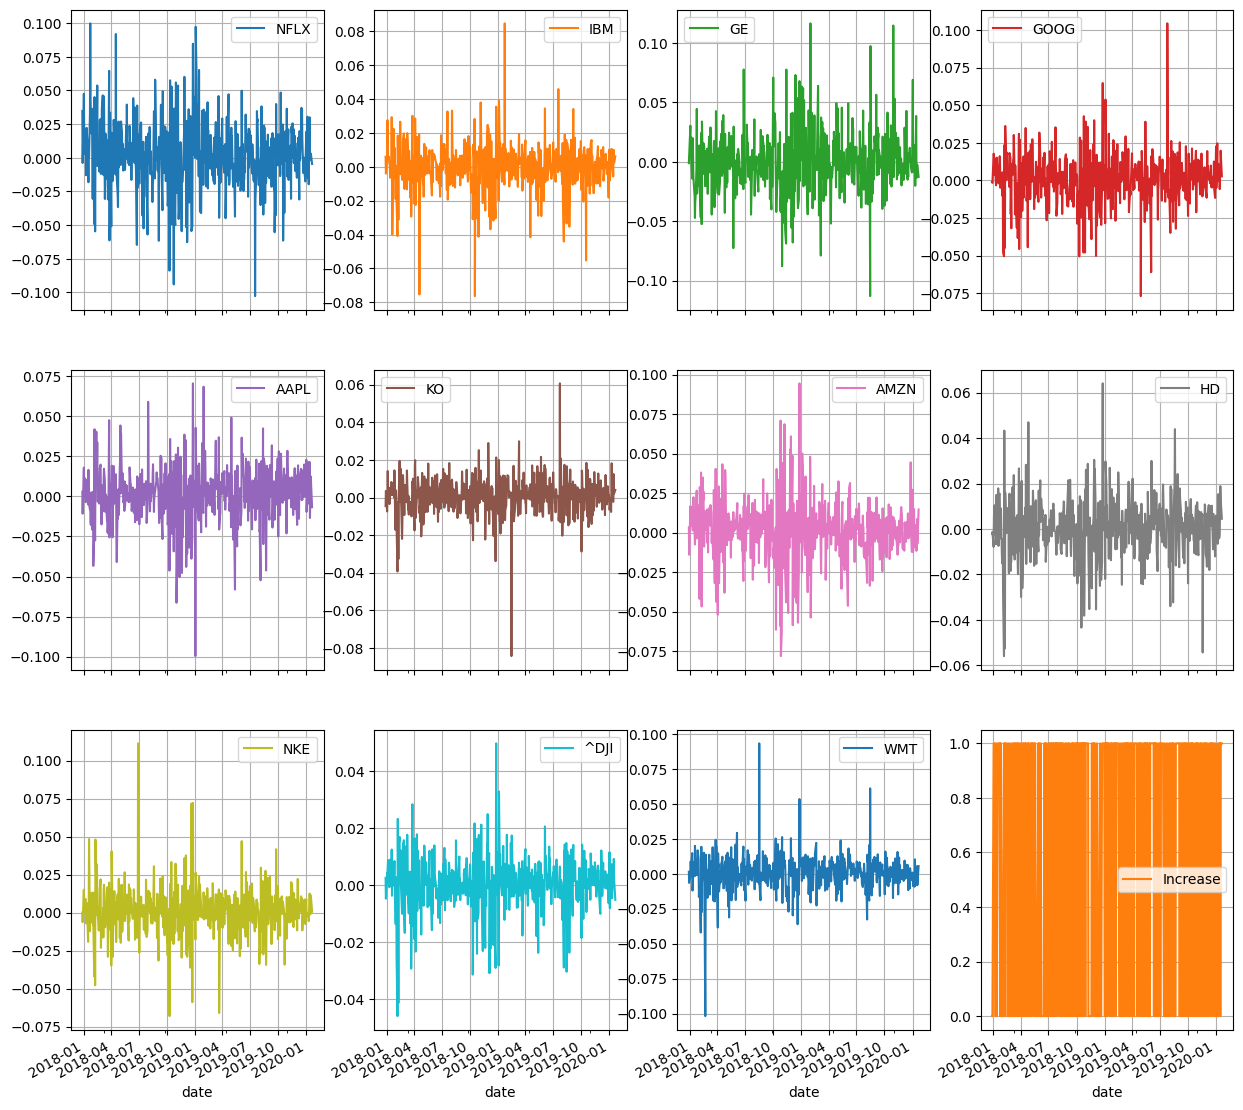

In [15]:
df.plot(subplots=True,
        grid=True,
        layout=(3,4),
         figsize=(15,15))
plt.show()

In [16]:
# # plot cumulative increase for ease
# tmp = df['Increase']
# tmp.replace(to_replace=0,value=-1, inplace=True)
# tmp = tmp.cumsum() # cumulative sum
# tmp.plot()
# plt.show()

# Data Partitioning

In [17]:
# Split data into X and Y
y = df['Increase']
X = df.drop('Increase', axis=1)
print(df.shape, X.shape, y.shape)

(518, 12) (518, 11) (518,)


In [18]:
# split the data into train and test partitions
# we will use 50% of the data for train, and rest for validation
train_pct_index = int(0.5 * len(X))
X_train, X_test = X[:train_pct_index], X[train_pct_index:]
y_train, y_test = y[:train_pct_index], y[train_pct_index:]

In [19]:
# X is still a 2D array
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)

(259, 11) (259,)
(259, 11) (259,)


In [20]:
# check for any missing vals
X_test.tail()

,NFLX,IBM,GE,GOOG,AAPL,KO,AMZN,HD,NKE,^DJI,WMT
date,,,,,,,,,,,
2020-01-14,-0.000679,-0.005709,-0.007426,-0.005802,-0.013504,-0.002316,-0.011558,-0.002373,0.007440,0.001128,0.002588
2020-01-15,0.001122,0.005890,-0.013300,0.005815,-0.004285,0.012499,-0.003969,0.007989,-0.001264,0.003129,-0.007748
2020-01-16,-0.001327,0.009955,-0.002527,0.008686,0.012526,0.002116,0.008550,0.018835,0.005642,0.009212,0.005381
2020-01-17,0.003101,0.002391,-0.002533,0.019762,0.011071,0.002112,-0.007040,0.013503,0.011223,0.001722,-0.008113
2020-01-21,-0.004593,0.006218,-0.012702,0.002708,-0.006776,0.004039,0.014630,0.004485,0.000478,-0.005181,0.005481


# Normalize the Data


In [21]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler() # this like 2D data
X_train = scaler.fit_transform(X_train) # fit and transform
X_test = scaler.transform(X_test) # transform simply means APPLY the learned coordinate
print(X_train.shape, X_test.shape)

(259, 11) (259, 11)


# Transform the shape
In order to use our function, we will join back X_train and y_train; and then X_test and y_test. Then we will need to run split_sequences TWICE (once for train, once for test).

In [22]:
# save everything as a dataframe
X_train = pd.DataFrame(X_train)
X_test = pd.DataFrame(X_test)
y_train = pd.DataFrame(y_train)
y_test = pd.DataFrame(y_test)

# reset the index on everything
# issue with dates and integers
X_train.reset_index(inplace=True, drop=True)
X_test.reset_index(inplace=True, drop=True)
y_train.reset_index(inplace=True, drop=True)
y_test.reset_index(inplace=True, drop=True)

# put X_train and y_train together (we did not scale Y)
# put X_test and y_test together (again, we did not scale Y before)
df_train = pd.concat([X_train, y_train], axis=1)
df_test = pd.concat([X_test, y_test], axis=1)
print(df.shape, df_train.shape, df_test.shape)

(518, 12) (259, 12) (259, 12)


In [23]:
# check the head
df_train.head()

,0,1,2,3,4,5,6,7,8,9,10,Increase
0,1.086535,0.422262,0.046668,-0.079800,0.156269,-0.503914,0.073639,-0.148771,-0.052770,0.229786,0.092865,0.0
1,-0.216627,-0.218563,0.297156,-0.107202,-0.557255,0.342897,-0.684157,-0.090113,-0.399572,-0.409759,-0.441126,0.0
2,1.515537,0.388116,1.293193,0.982564,0.946458,-0.801821,0.664315,-0.551777,0.767296,0.377369,-0.110670,1.0
3,0.582365,1.807614,0.466091,0.906165,-0.000148,-0.254559,0.491721,0.366818,-0.061372,0.354250,0.584054,1.0
4,0.010072,1.342481,0.920082,0.188875,0.252107,1.453729,0.127526,0.557532,-0.087181,0.541567,0.058842,1.0


In [24]:
# check the head
df_test.head()

,0,1,2,3,4,5,6,7,8,9,10,Increase
0,0.410167,0.626228,2.139199,-0.239945,0.176220,1.102335,-0.153514,-0.258824,-0.173909,0.456367,0.047708,0.0
1,1.258105,-0.133965,0.092150,-0.702510,-0.505001,0.577651,-0.483813,0.138920,-0.324092,-0.015066,-0.086779,1.0
2,-0.549982,-0.526173,-0.084786,-0.677016,-0.778399,-0.445093,-0.693469,-0.231977,-0.016860,-0.307100,0.075988,1.0
3,2.113250,0.755896,-0.663209,1.728071,1.080595,0.910309,1.487281,-0.913772,1.230929,0.576290,0.918020,1.0
4,-0.394478,-0.017884,1.224603,0.184730,0.648598,-1.457997,0.172721,0.228127,-0.192861,0.521082,0.067828,1.0


In [25]:
# split a multivariate sequence into samples
def split_sequences(sequences, n_steps):
	X, y = list(), list()
	for i in range(0,len(sequences)): # UPDATED FOR N_STEPS
		# find the end of this pattern
		end_ix = i + n_steps
		# check if we are beyond the dataset
		if end_ix > len(sequences):
			break
		# gather input and output parts of the pattern
		seq_x, seq_y = sequences[i:end_ix, :-1], sequences[end_ix-1, -1]
		X.append(seq_x)
		y.append(seq_y)
	return np.array(X), np.array(y)

In [26]:
# almost ready to play
n_steps = 5
X_train, y_train = split_sequences(np.array(df_train), n_steps)
X_test, y_test = split_sequences(np.array(df_test), n_steps)
# check your work
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape) # looks good!

(255, 5, 11) (255,)
(255, 5, 11) (255,)


Play with different time steps! 3, 5, 10, 20... any luck?

In [27]:
# verify no NaN values
print(np.isnan(X_train).sum())
print(np.isnan(y_train).sum())
print(np.isnan(X_test).sum())
print(np.isnan(y_test).sum())

0
0
0
0


In [28]:
# verify distribution of target variable
print(np.unique(y_train, return_counts=True))
print(np.unique(y_test, return_counts=True))

(array([0., 1.]), array([128, 127]))
(array([0., 1.]), array([111, 144]))


# LSTM - Stock Market Binary Classification

In [29]:
# define what you need
n_steps = X_train.shape[1]
n_features = X_train.shape[2]

# define model
model = Sequential()
model.add((LSTM(64, return_sequences=True, activation='relu',
                input_shape=(n_steps, n_features))))
model.add(Dropout(0.1))
model.add((LSTM(32,activation='relu')))
model.add(Dropout(0.1))
model.add(Dense(32,activation='relu'))
model.add(Dropout(0.1))
model.add(Dense(1, activation='sigmoid'))
model.summary()

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

# early stopping
es = EarlyStopping(monitor='val_accuracy',
                   mode='max',
                   patience=20,
                   verbose=1,
                   restore_best_weights=True)

# fit model, if you run locally and remember the seed, you will be able to rerun 6 epochs and get the best val accuracy
model.fit(X_train, y_train,
          epochs=100,
          batch_size=5,
          validation_data=(X_test, y_test),
          verbose=1,
          callbacks=[es],
          shuffle=True)

C:\Users\dww05002\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 5, 64)          │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 32,961 (128.75 KB)

 Trainable params: 32,961 (128.75 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/100


 1/51 ━━━━━━━━━━━━━━━━━━━━ 13:56 17s/step - accuracy: 0.2000 - loss: 0.7221

 8/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4500 - loss: 0.6986   

16/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4375 - loss: 0.6978

24/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4833 - loss: 0.6956

31/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4323 - loss: 0.6959

38/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4474 - loss: 0.6956

46/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4478 - loss: 0.6954

51/51 ━━━━━━━━━━━━━━━━━━━━ 19s 52ms/step - accuracy: 0.4588 - loss: 0.6952 - val_accuracy: 0.4275 - val_loss: 0.6936


Epoch 2/100


 1/51 ━━━━━━━━━━━━━━━━━━━━ 7s 148ms/step - accuracy: 0.4000 - loss: 0.6926

 8/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.3500 - loss: 0.6951  

15/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4133 - loss: 0.6937

23/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4435 - loss: 0.6936

31/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4645 - loss: 0.6931

39/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4564 - loss: 0.6939

47/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4681 - loss: 0.6937

51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.4784 - loss: 0.6936 - val_accuracy: 0.5216 - val_loss: 0.6930


Epoch 3/100


 1/51 ━━━━━━━━━━━━━━━━━━━━ 28s 566ms/step - accuracy: 0.8000 - loss: 0.6896

 7/51 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5429 - loss: 0.6919   

14/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5857 - loss: 0.6900

20/51 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5800 - loss: 0.6904

26/51 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5692 - loss: 0.6904

32/51 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5312 - loss: 0.6917

38/51 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5368 - loss: 0.6920

44/51 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5318 - loss: 0.6926

49/51 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5388 - loss: 0.6923

51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 18ms/step - accuracy: 0.5412 - loss: 0.6921 - val_accuracy: 0.4941 - val_loss: 0.6935


Epoch 4/100


 1/51 ━━━━━━━━━━━━━━━━━━━━ 7s 147ms/step - accuracy: 0.6000 - loss: 0.6812

 8/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6000 - loss: 0.6916  

14/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5714 - loss: 0.6897

20/51 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5600 - loss: 0.6899

27/51 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5630 - loss: 0.6872

33/51 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5455 - loss: 0.6909

39/51 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5487 - loss: 0.6910

45/51 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5467 - loss: 0.6908

50/51 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5400 - loss: 0.6909

51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5373 - loss: 0.6911 - val_accuracy: 0.4275 - val_loss: 0.6959


Epoch 5/100


 1/51 ━━━━━━━━━━━━━━━━━━━━ 7s 140ms/step - accuracy: 0.6000 - loss: 0.6878

 7/51 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.4857 - loss: 0.6879  

13/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5538 - loss: 0.6818

19/51 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6105 - loss: 0.6820

26/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6000 - loss: 0.6807

33/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5758 - loss: 0.6834

38/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5842 - loss: 0.6821

44/51 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5864 - loss: 0.6828

49/51 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5918 - loss: 0.6820

51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 29ms/step - accuracy: 0.5882 - loss: 0.6820 - val_accuracy: 0.4902 - val_loss: 0.6960


Epoch 6/100


 1/51 ━━━━━━━━━━━━━━━━━━━━ 7s 148ms/step - accuracy: 0.8000 - loss: 0.6322

 7/51 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5429 - loss: 0.6831 

13/51 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5538 - loss: 0.6718

18/51 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5889 - loss: 0.6654

23/51 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5652 - loss: 0.6700

28/51 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6000 - loss: 0.6613

32/51 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5938 - loss: 0.6714

37/51 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5784 - loss: 0.6770

42/51 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5810 - loss: 0.6754

48/51 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5667 - loss: 0.6780

51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 30ms/step - accuracy: 0.5686 - loss: 0.6780 - val_accuracy: 0.4549 - val_loss: 0.7033


Epoch 7/100


 1/51 ━━━━━━━━━━━━━━━━━━━━ 10s 215ms/step - accuracy: 0.6000 - loss: 0.5944

 8/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5750 - loss: 0.6651   

15/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6133 - loss: 0.6448

23/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5913 - loss: 0.6522

30/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5800 - loss: 0.6510

34/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5824 - loss: 0.6567

40/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5900 - loss: 0.6531

46/51 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5913 - loss: 0.6553

48/51 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6000 - loss: 0.6526

51/51 ━━━━━━━━━━━━━━━━━━━━ 2s 27ms/step - accuracy: 0.6000 - loss: 0.6548 - val_accuracy: 0.4627 - val_loss: 0.7064


Epoch 8/100


 1/51 ━━━━━━━━━━━━━━━━━━━━ 8s 178ms/step - accuracy: 0.8000 - loss: 0.5322

 7/51 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6000 - loss: 0.6530  

13/51 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6154 - loss: 0.6412

19/51 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6316 - loss: 0.6255

21/51 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6571 - loss: 0.6172

27/51 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6370 - loss: 0.6050

32/51 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6250 - loss: 0.6234

38/51 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6263 - loss: 0.6366

43/51 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6186 - loss: 0.6469

49/51 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6204 - loss: 0.6458

51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 22ms/step - accuracy: 0.6118 - loss: 0.6474 - val_accuracy: 0.4392 - val_loss: 0.7139


Epoch 9/100


 1/51 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - accuracy: 1.0000 - loss: 0.4777

 8/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6500 - loss: 0.6442  

13/51 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6769 - loss: 0.6276

17/51 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6941 - loss: 0.6142

23/51 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6696 - loss: 0.6205

29/51 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.6828 - loss: 0.6137

33/51 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6667 - loss: 0.6289

39/51 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6667 - loss: 0.6296

45/51 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6578 - loss: 0.6360

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.6549 - loss: 0.6458

51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.6549 - loss: 0.6458 - val_accuracy: 0.4196 - val_loss: 0.7184


Epoch 10/100


 1/51 ━━━━━━━━━━━━━━━━━━━━ 4s 81ms/step - accuracy: 1.0000 - loss: 0.4607

 9/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5556 - loss: 0.6619 

16/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6375 - loss: 0.6109

24/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6333 - loss: 0.6151

31/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6323 - loss: 0.6204

38/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6474 - loss: 0.6161

46/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6478 - loss: 0.6212

51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6353 - loss: 0.6260 - val_accuracy: 0.4314 - val_loss: 0.7381


Epoch 11/100


 1/51 ━━━━━━━━━━━━━━━━━━━━ 2s 58ms/step - accuracy: 0.6000 - loss: 0.5553

10/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7200 - loss: 0.6311 

18/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7222 - loss: 0.5905

27/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7111 - loss: 0.5798

36/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7000 - loss: 0.5926

43/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6884 - loss: 0.6074

51/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6863 - loss: 0.6084

51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.6863 - loss: 0.6084 - val_accuracy: 0.4392 - val_loss: 0.7607


Epoch 12/100


 1/51 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.6000 - loss: 0.6284

 9/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6222 - loss: 0.6351 

16/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6625 - loss: 0.5795

22/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6636 - loss: 0.5960

29/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6759 - loss: 0.5856

37/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6757 - loss: 0.5904

46/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6696 - loss: 0.6004

51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6706 - loss: 0.6023 - val_accuracy: 0.4392 - val_loss: 0.7682


Epoch 13/100


 1/51 ━━━━━━━━━━━━━━━━━━━━ 3s 62ms/step - accuracy: 0.8000 - loss: 0.4628

10/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6800 - loss: 0.6013 

18/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7000 - loss: 0.5671

26/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6846 - loss: 0.5618

34/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6765 - loss: 0.5781

42/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6714 - loss: 0.5738

49/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6612 - loss: 0.5887

51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6549 - loss: 0.5912 - val_accuracy: 0.4353 - val_loss: 0.7851


Epoch 14/100


 1/51 ━━━━━━━━━━━━━━━━━━━━ 3s 70ms/step - accuracy: 0.8000 - loss: 0.5229

 9/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5556 - loss: 0.6475 

17/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6706 - loss: 0.5764

24/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6750 - loss: 0.5686

32/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6875 - loss: 0.5770

40/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6800 - loss: 0.5776

48/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6708 - loss: 0.5828

51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6706 - loss: 0.5846 - val_accuracy: 0.4471 - val_loss: 0.7897


Epoch 15/100


 1/51 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.6000 - loss: 0.5442

 9/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6889 - loss: 0.6126 

17/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7529 - loss: 0.5434

25/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7280 - loss: 0.5364

34/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7353 - loss: 0.5534

42/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7381 - loss: 0.5512

50/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7280 - loss: 0.5607

51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7255 - loss: 0.5623 - val_accuracy: 0.4353 - val_loss: 0.8134


Epoch 16/100


 1/51 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.8000 - loss: 0.4481

10/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7000 - loss: 0.5757 

19/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7158 - loss: 0.5340

28/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7286 - loss: 0.5097

36/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7222 - loss: 0.5267

45/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7111 - loss: 0.5308

51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7020 - loss: 0.5372 - val_accuracy: 0.4392 - val_loss: 0.8966


Epoch 17/100


 1/51 ━━━━━━━━━━━━━━━━━━━━ 2s 52ms/step - accuracy: 0.8000 - loss: 0.4138

 9/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7333 - loss: 0.6101 

17/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7529 - loss: 0.5414

24/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7250 - loss: 0.5237

32/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7375 - loss: 0.5310

40/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7200 - loss: 0.5288

48/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7042 - loss: 0.5347

51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7020 - loss: 0.5388 - val_accuracy: 0.4431 - val_loss: 0.8816


Epoch 18/100


 1/51 ━━━━━━━━━━━━━━━━━━━━ 33s 674ms/step - accuracy: 0.6000 - loss: 0.5415

11/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6727 - loss: 0.5687   

21/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7143 - loss: 0.5038

31/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7290 - loss: 0.4983

41/51 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7317 - loss: 0.5005

49/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7184 - loss: 0.5130

51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7098 - loss: 0.5188 - val_accuracy: 0.4431 - val_loss: 0.9251


Epoch 19/100


 1/51 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.6000 - loss: 0.4407

 9/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6889 - loss: 0.6016 

16/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7625 - loss: 0.5335

23/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7391 - loss: 0.5122

31/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7419 - loss: 0.5223

39/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7385 - loss: 0.5044

46/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7304 - loss: 0.5166

51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7216 - loss: 0.5193 - val_accuracy: 0.4118 - val_loss: 1.0003


Epoch 20/100


 1/51 ━━━━━━━━━━━━━━━━━━━━ 34s 689ms/step - accuracy: 0.8000 - loss: 0.3748

10/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7600 - loss: 0.5656   

19/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7368 - loss: 0.4917

28/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7714 - loss: 0.4559

36/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7778 - loss: 0.4553

44/51 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7591 - loss: 0.4811

51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.7412 - loss: 0.4903 - val_accuracy: 0.4353 - val_loss: 1.1234


Epoch 21/100


 1/51 ━━━━━━━━━━━━━━━━━━━━ 5s 114ms/step - accuracy: 0.4000 - loss: 0.7305

 8/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.6500 - loss: 0.5879  

14/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7143 - loss: 0.5276

21/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7429 - loss: 0.4990

28/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7500 - loss: 0.4805

35/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7543 - loss: 0.4745

42/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7619 - loss: 0.4627

49/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7510 - loss: 0.4686

51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7373 - loss: 0.4774 - val_accuracy: 0.4392 - val_loss: 1.2200


Epoch 22/100


 1/51 ━━━━━━━━━━━━━━━━━━━━ 5s 109ms/step - accuracy: 0.8000 - loss: 0.4305

 8/51 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6750 - loss: 0.5642  

14/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7857 - loss: 0.4666

21/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7810 - loss: 0.4369

27/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7778 - loss: 0.4288

34/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7765 - loss: 0.4316

40/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7850 - loss: 0.4317

47/51 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7617 - loss: 0.4518

51/51 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7529 - loss: 0.4552 - val_accuracy: 0.4353 - val_loss: 1.2529


Epoch 22: early stopping


Restoring model weights from the end of the best epoch: 2.


In [30]:
# you may get different results every time!
# depends on your use of validation data

You can also try to predict how much the Dow will go up or down the next day (percentage - play around with this example! And don't forget to change your metrics in compile or activation function in the last layer.

1/8 ━━━━━━━━━━━━━━━━━━━━ 6s 977ms/step

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 117ms/step

8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 124ms/step


[[44 67]
 [55 89]]
              precision    recall  f1-score   support

         0.0       0.44      0.40      0.42       111
         1.0       0.57      0.62      0.59       144

    accuracy                           0.52       255
   macro avg       0.51      0.51      0.51       255
weighted avg       0.52      0.52      0.52       255



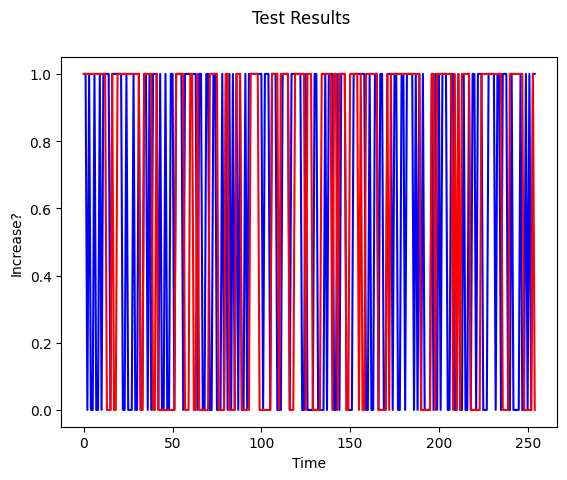

In [31]:
# put it all together for other models

# make a prediction
pred = model.predict(X_test)# the pred
# print(pred) # round them!

pred = np.round(pred,0)
# print(pred) # run all if you get an error...

# confusion matrix - put this at the top!
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report
print(confusion_matrix(y_test, pred)) # looks pretty good!
print(classification_report(y_test, pred))

# show timeseries plot on the train and validation data
plt.plot(np.arange(X_test.shape[0]), y_test, color='blue') # actual data
plt.plot(np.arange(X_test.shape[0]), pred, color='red') # predicted data
plt.suptitle('Test Results')
plt.xlabel('Time')
plt.ylabel('Increase?')
plt.show()

## Save the model and use it again

Reproducibility means more than a seed: **save the fitted model** so you (or a teammate, or your future self) can reload it and predict without retraining. Keras 3 saves to a single `.keras` file. The reloaded model must give *identical* predictions - we check.

In [32]:
from keras.models import load_model

model.save('Simple_Predict_The_Stock_Market_DL.keras')                 # one file: architecture + weights + optimizer state
reloaded = load_model('Simple_Predict_The_Stock_Market_DL.keras')

# same inputs, same answers?
import numpy as np
same = np.allclose(model.predict(X_test[:5], verbose=0), reloaded.predict(X_test[:5], verbose=0))
print('reloaded model reproduces the predictions:', same)
reloaded.summary()

reloaded model reproduces the predictions: True


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 5, 64)          │        19,456 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 5, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         1,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 98,885 (386.27 KB)

 Trainable params: 32,961 (128.75 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 65,924 (257.52 KB)